In [9]:
import os
import json
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter
from datetime import datetime

from geometry_param import get_params

In [10]:
# ============================================================
# LOAD TRAJECTORY
# ============================================================

traj_filename = "results/sim_data_04052026_0546.npz"

traj = np.load(traj_filename, allow_pickle=True)

t_hist  = traj['t']
n_hist  = traj['n']
nd_hist = traj['nd']

tau_true_hist = traj['tau'] if 'tau' in traj.files else None
F_true_hist   = traj['F']   if 'F' in traj.files else None

print("Trajectory loaded.")
print("t shape :", t_hist.shape)
print("n shape :", n_hist.shape)
print("nd shape:", nd_hist.shape)


Trajectory loaded.
t shape : (1000,)
n shape : (1000, 3)
nd shape: (1000, 3)


In [11]:
# ============================================================
# DESERIALIZATION
# ============================================================

SYMPY_LOCALS = {
    name: getattr(sp, name)
    for name in dir(sp)
}

SYMPY_LOCALS.update({
    "Derivative": sp.Derivative
})

def deserialize_fast(obj):

    if isinstance(obj, dict) and "__sympy__" in obj:
        return eval(obj["expr"], SYMPY_LOCALS)

    elif isinstance(obj, dict):
        return {
            k: deserialize_fast(v)
            for k, v in obj.items()
        }

    elif isinstance(obj, list):
        return [
            deserialize_fast(v)
            for v in obj
        ]

    else:
        return obj


In [25]:
# ============================================================
# LOAD SYMBOLIC MODEL
# ============================================================

symbolic_filename = "cache/3DOF_symbolic_data_08052026_1944.json"

with open(symbolic_filename, "r") as f:
    raw = json.load(f)

data = deserialize_fast(raw)

print("Symbolic model loaded.")

Symbolic model loaded.


In [13]:
# ============================================================
# EXTRACT SYMBOLICS
# ============================================================

M_sym = data['M']
h_sym = data['h']
Q_sym = data['Q']

C_AN_sym   = data['C_AN']
Jv_b_N_sym = data['Jv_b_N']
Jw_b_B_sym = data['Jw_b_B']


In [14]:
# ============================================================
# STATES
# ============================================================

n   = data['n']
nd  = data['nd']
ndd = data['ndd']

params_sym = data['params']


In [15]:
# ============================================================
# BUILD ARGUMENT LIST
# ============================================================

state_syms = list(n) + list(nd)

param_syms = list(params_sym.values())

tau_syms = sp.symbols('tau1 tau2 tau3')
F_syms   = sp.symbols('Fx Fy Fz')

dyn_args = (
    *state_syms,
    *param_syms,
    *tau_syms,
    *F_syms
)

In [16]:
# ============================================================
# CHECK SYMBOL CONSISTENCY
# ============================================================

free_syms = (
    M_sym.free_symbols
    | h_sym.free_symbols
    | Q_sym.free_symbols
    | C_AN_sym.free_symbols
    | Jv_b_N_sym.free_symbols
    | Jw_b_B_sym.free_symbols
)

missing = free_syms - set(dyn_args)

print("\nMissing symbols:")
print(missing)


Missing symbols:
set()


In [17]:
# ============================================================
# NUMERIC PARAMETERS
# ============================================================

params_num = get_params()

param_vals = list(params_num.values())


In [18]:
# ============================================================
# LAMBDIFY
# ============================================================

print("\nLambdifying dynamics...")

M_func = sp.lambdify(
    dyn_args,
    M_sym,
    modules='numpy'
)

h_func = sp.lambdify(
    dyn_args,
    h_sym,
    modules='numpy'
)

Q_func = sp.lambdify(
    dyn_args,
    Q_sym,
    modules='numpy'
)

print("Lambdifying Jacobians...")

Jv_func = sp.lambdify(
    dyn_args,
    Jv_b_N_sym,
    modules='numpy'
)

Jw_func = sp.lambdify(
    dyn_args,
    Jw_b_B_sym,
    modules='numpy'
)

CAN_func = sp.lambdify(
    dyn_args,
    C_AN_sym,
    modules='numpy'
)

print("Done.\n")



Lambdifying dynamics...
Lambdifying Jacobians...
Done.



In [19]:
# ============================================================
# ACCELERATION ESTIMATION
# ============================================================

print("Estimating accelerations...")

dt_mean = np.mean(np.diff(t_hist))

window_length = 21
polyorder      = 3

ndd_hist = savgol_filter(
    nd_hist,
    window_length=window_length,
    polyorder=polyorder,
    deriv=1,
    delta=dt_mean,
    axis=0
)

print("ndd shape:", ndd_hist.shape)


Estimating accelerations...
ndd shape: (1000, 3)


In [20]:
# ============================================================
# CONSTANT WRENCH MODEL
#
# tau = b + A F
#
# A skew-symmetric
# ============================================================

# ------------------------------------------------------------
# CONSTANT VECTOR b
# ------------------------------------------------------------

b_vec = np.array([
    0.0,
    0.0,
    0.0
])

# ------------------------------------------------------------
# SKEW-SYMMETRIC MATRIX PARAMETERS
# ------------------------------------------------------------

a1 = 0.08
a2 = -0.04
a3 = 0.06

A_mat = np.array([
    [0.0, -a3,  a2],
    [a3,  0.0, -a1],
    [-a2, a1,  0.0]
])

print("\nA matrix:")
print(A_mat)

print("\nb vector:")
print(b_vec)


A matrix:
[[ 0.   -0.06 -0.04]
 [ 0.06  0.   -0.08]
 [ 0.04  0.08  0.  ]]

b vector:
[0. 0. 0.]


In [21]:
# ============================================================
# STORAGE
# ============================================================

N = len(t_hist)

F_est_hist   = np.zeros((N,3))
tau_est_hist = np.zeros((N,3))

Q_hist    = np.zeros((N,3))
cond_hist = np.zeros(N)


In [22]:
# ============================================================
# ESTIMATION LOOP
# ============================================================

print("\nEstimating forces and torques...\n")

for k in range(N):

    # ========================================================
    # STATES
    # ========================================================

    q   = n_hist[k]
    qd  = nd_hist[k]
    qdd = ndd_hist[k]

    n1, n2, n3       = q
    n1d, n2d, n3d    = qd

    # ========================================================
    # DUMMY INPUTS
    # ========================================================

    tau_dummy = [0.0, 0.0, 0.0]
    F_dummy   = [0.0, 0.0, 0.0]

    # ========================================================
    # FULL ARGUMENT VECTOR
    # ========================================================

    args = (
        n1, n2, n3,
        n1d, n2d, n3d,

        *param_vals,

        *tau_dummy,
        *F_dummy
    )

    # ========================================================
    # DYNAMICS
    #
    # Q = M qdd + h
    # ========================================================

    M_k = np.array(
        M_func(*args),
        dtype=float
    )

    h_k = np.array(
        h_func(*args),
        dtype=float
    ).reshape(3)

    Q_k = M_k @ qdd + h_k

    # ========================================================
    # JACOBIANS
    # ========================================================

    Jv_N_k = np.array(
        Jv_func(*args),
        dtype=float
    )

    Jw_k = np.array(
        Jw_func(*args),
        dtype=float
    )

    C_AN_k = np.array(
        CAN_func(*args),
        dtype=float
    )

    # ========================================================
    # BODY-FRAME TRANSLATIONAL JACOBIAN
    # ========================================================

    Jv_B_k = C_AN_k @ Jv_N_k

    # ========================================================
    # ESTIMATION MATRIX
    #
    # Q = (Jv^T + Jw^T A)F + Jw^T b
    # ========================================================

    H_k = (
        Jv_B_k.T
        + Jw_k.T @ A_mat
    )

    c_k = Jw_k.T @ b_vec

    # ========================================================
    # CONDITION NUMBER
    # ========================================================

    cond_hist[k] = np.linalg.cond(H_k)

    # ========================================================
    # FORCE ESTIMATION
    # ========================================================

    rhs = Q_k - c_k

    F_est = np.linalg.pinv(H_k) @ rhs

    # ========================================================
    # TORQUE RECOVERY
    # ========================================================

    tau_est = b_vec + A_mat @ F_est

    # ========================================================
    # SAVE
    # ========================================================

    F_est_hist[k]   = F_est
    tau_est_hist[k] = tau_est
    Q_hist[k]       = Q_k

print("Estimation complete.\n")


Estimating forces and torques...

Estimation complete.



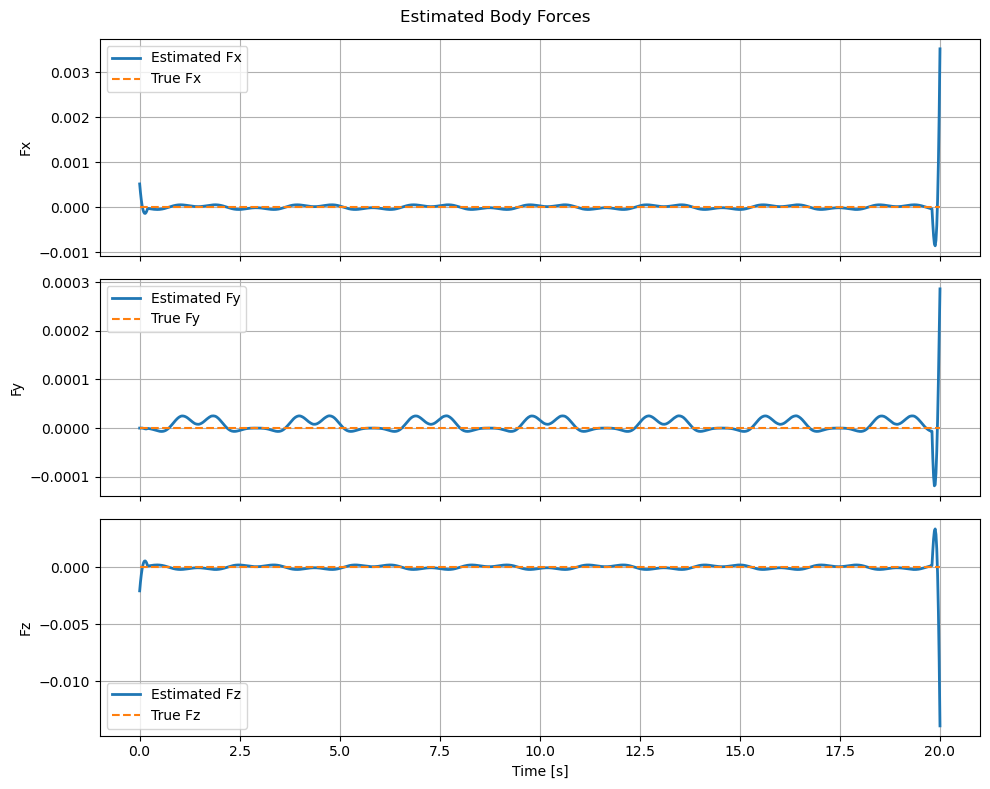

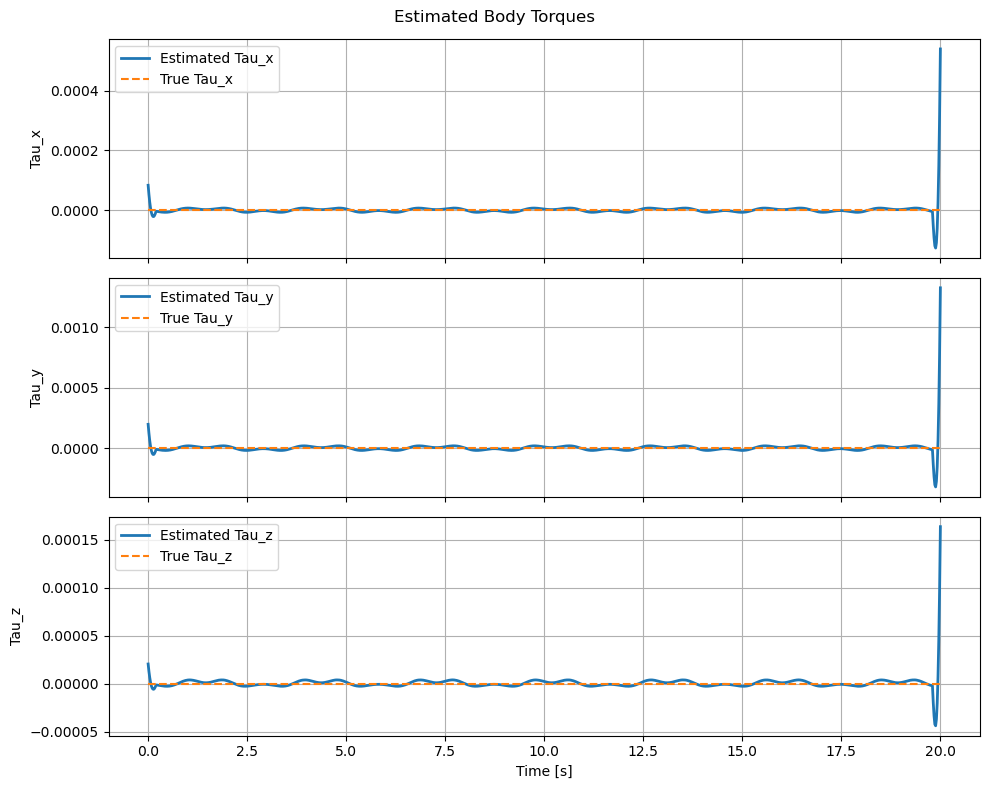

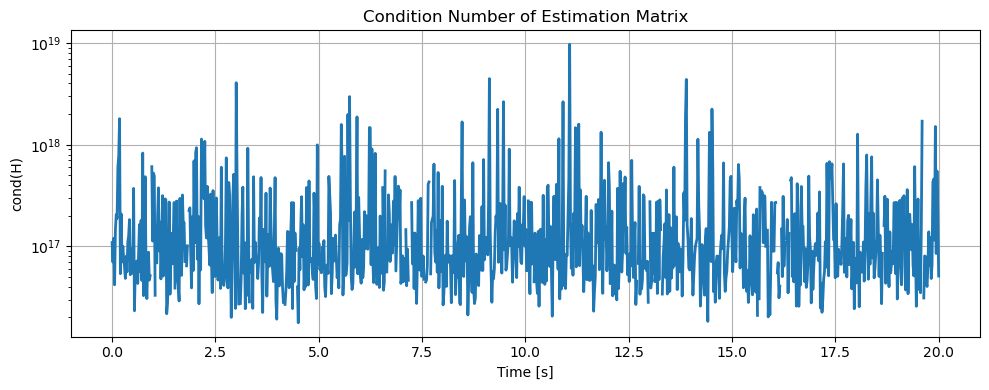

In [23]:
# ============================================================
# FORCE PLOTS
# ============================================================

figF, axF = plt.subplots(
    3,
    1,
    figsize=(10,8),
    sharex=True
)

force_labels = ['Fx', 'Fy', 'Fz']

for i in range(3):

    axF[i].plot(
        t_hist,
        F_est_hist[:,i],
        linewidth=2,
        label=f'Estimated {force_labels[i]}'
    )

    if F_true_hist is not None:

        axF[i].plot(
            t_hist,
            F_true_hist[:,i],
            '--',
            linewidth=1.5,
            label=f'True {force_labels[i]}'
        )

    axF[i].set_ylabel(force_labels[i])

    axF[i].grid(True)

    axF[i].legend()

axF[-1].set_xlabel('Time [s]')

figF.suptitle('Estimated Body Forces')

plt.tight_layout()

# ============================================================
# TORQUE PLOTS
# ============================================================

figTau, axTau = plt.subplots(
    3,
    1,
    figsize=(10,8),
    sharex=True
)

tau_labels = ['Tau_x', 'Tau_y', 'Tau_z']

for i in range(3):

    axTau[i].plot(
        t_hist,
        tau_est_hist[:,i],
        linewidth=2,
        label=f'Estimated {tau_labels[i]}'
    )

    if tau_true_hist is not None:

        axTau[i].plot(
            t_hist,
            tau_true_hist[:,i],
            '--',
            linewidth=1.5,
            label=f'True {tau_labels[i]}'
        )

    axTau[i].set_ylabel(tau_labels[i])

    axTau[i].grid(True)

    axTau[i].legend()

axTau[-1].set_xlabel('Time [s]')

figTau.suptitle('Estimated Body Torques')

plt.tight_layout()

# ============================================================
# CONDITION NUMBER PLOT
# ============================================================

plt.figure(figsize=(10,4))

plt.plot(
    t_hist,
    cond_hist,
    linewidth=2
)

plt.yscale('log')

plt.grid(True)

plt.xlabel('Time [s]')

plt.ylabel('cond(H)')

plt.title('Condition Number of Estimation Matrix')

plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# OPTIONAL SAVE
# ============================================================

SAVE_ESTIMATION = False

if SAVE_ESTIMATION:

    save_dir = "results"

    os.makedirs(save_dir, exist_ok=True)

    timestamp_now = datetime.now().strftime("%d%m%Y_%H%M")

    save_filename = os.path.join(
        save_dir,
        f"estimated_wrench_{timestamp_now}.npz"
    )

    np.savez_compressed(
        save_filename,

        t=t_hist,

        F_est=F_est_hist,
        tau_est=tau_est_hist,

        Q=Q_hist,

        condH=cond_hist,

        A=A_mat,
        b=b_vec
    )

    print(f"\nSaved estimated wrench data to:\n{save_filename}")